In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

labels = "epoch, wall, LR,training_loss_f,training_loss_e,training_loss,training_f_mae,training_f_rmse,training_e_mae,training_e/N_mae,validation_loss_f,validation_loss_e,validation_loss,validation_f_mae,validation_f_rmse,validation_e_mae,validation_e/N_mae".split(',')




In [3]:
# All calcs here performed with adam optimizer with train step 0.001
# Number of trainable weights 4920
# placeholder

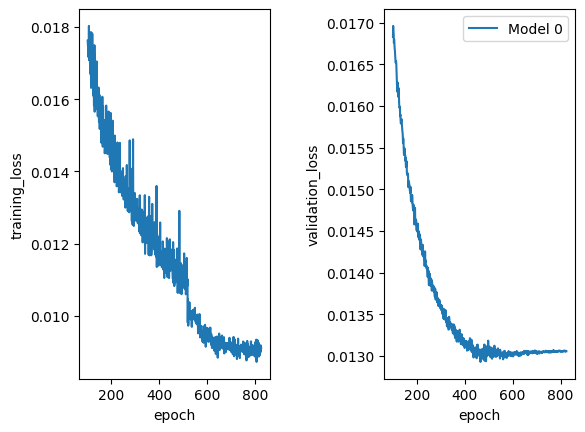

In [4]:
# Loss
fig, axes = plt.subplots(1, 2)

for i in range(1):
    
    data = np.genfromtxt(f'./results/MEA_Allegro_{i}/example/metrics_epoch.csv', skip_header=1, delimiter=",")
    
    axes[0].plot(data[100:, 0], data[100:, 5], label = f'Model {i}')

    axes[1].plot(data[100:, 0], data[100:, -5], label = f'Model {i}')
    
axes[0].set_ylabel(labels[5])
axes[1].set_ylabel(labels[-5])

axes[0].set_xlabel(labels[0])
axes[1].set_xlabel(labels[0])
plt.legend()

plt.subplots_adjust(wspace = 0.6)
#plt.title(labels[5], fontsize = 20)

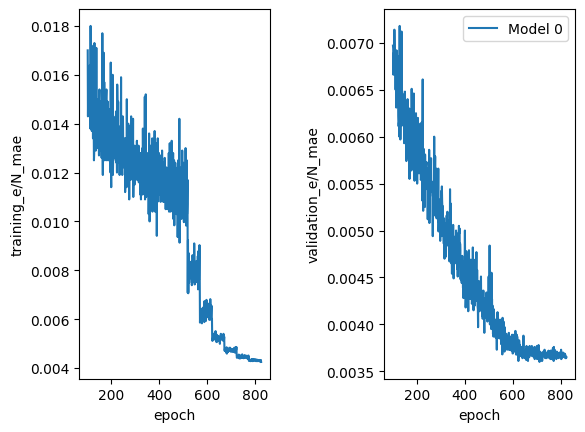

In [5]:
# train E/N
fig, axes = plt.subplots(1, 2)

for i in range(1):
    
    data = np.genfromtxt(f'./results/MEA_Allegro_{i}/example/metrics_epoch.csv', skip_header=1, delimiter=",")
    
    axes[0].plot(data[100:, 0], data[100:, 9], label = f'Model {i}')

    axes[1].plot(data[100:, 0], data[100:, -1], label = f'Model {i}')
    
axes[0].set_ylabel(labels[9])
axes[1].set_ylabel(labels[-1])

axes[0].set_xlabel(labels[0])
axes[1].set_xlabel(labels[0])
plt.legend()

plt.subplots_adjust(wspace = 0.6)

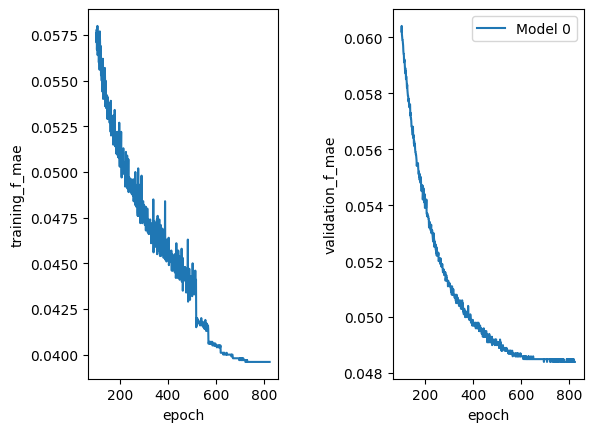

In [6]:
# train fmae
fig, axes = plt.subplots(1, 2)

for i in range(1):
    
    data = np.genfromtxt(f'./results/MEA_Allegro_{i}/example/metrics_epoch.csv', skip_header=1, delimiter=",")
    
    axes[0].plot(data[100:, 0], data[100:, 6], label = f'Model {i}')

    axes[1].plot(data[100:, 0], data[100:, -4], label = f'Model {i}')
    
axes[0].set_ylabel(labels[6])
axes[1].set_ylabel(labels[-4])

axes[0].set_xlabel(labels[0])
axes[1].set_xlabel(labels[0])
plt.legend()

plt.subplots_adjust(wspace = 0.6)

In [7]:
# reference example
from nequip.data import dataset_from_config
from nequip.utils import Config
#from nequip.utils.misc import get_default_device_name
#from nequip.utils.config import _GLOBAL_ALL_ASKED_FOR_KEYS
import os
from nequip.model import model_from_config


default_config = dict(
    root="./",
    tensorboard=False,
    wandb=False,
    model_builders=[
        "SimpleIrrepsConfig",
        "EnergyModel",
        "PerSpeciesRescale",
        "StressForceOutput",
        "RescaleEnergyEtc",
    ],
    dataset_statistics_stride=1,
    device='cpu',
    default_dtype="float64",
    model_dtype="float32",
    allow_tf32=True,
    verbose="INFO",
    model_debug_mode=False,
    equivariance_test=False,
    grad_anomaly_mode=False,
    gpu_oom_offload=False,
    append=False,
    warn_unused=False,
    _jit_bailout_depth=2,  # avoid 20 iters of pain, see https://github.com/pytorch/pytorch/issues/52286
    # Quote from eelison in PyTorch slack:
    # https://pytorch.slack.com/archives/CDZD1FANA/p1644259272007529?thread_ts=1644064449.039479&cid=CDZD1FANA
    # > Right now the default behavior is to specialize twice on static shapes and then on dynamic shapes.
    # > To reduce warmup time you can do something like setFusionStrartegy({{FusionBehavior::DYNAMIC, 3}})
    # > ... Although we would wouldn't really expect to recompile a dynamic shape fusion in a model,
    # > provided broadcasting patterns remain fixed
    # We default to DYNAMIC alone because the number of edges is always dynamic,
    # even if the number of atoms is fixed:
    _jit_fusion_strategy=[("DYNAMIC", 3)],
    # Due to what appear to be ongoing bugs with nvFuser, we default to NNC (fuser1) for now:
    # TODO: still default to NNC on CPU regardless even if change this for GPU
    # TODO: default for ROCm?
    _jit_fuser="fuser1",
)

os.environ['NEQUIP_NUM_TASKS'] = '1'
# All default_config keys are valid / requested
#_GLOBAL_ALL_ASKED_FOR_KEYS.update(default_config.keys())

In [8]:
config = Config.from_file('./results/MEA_Allegro_0/example/config.yaml', defaults=default_config)
config['root'] = f'results/MEA_Allegro_0' 

dataset = dataset_from_config(config, prefix="dataset")

validation_dataset = None

dataset[0]

AtomicData(atom_types=[54, 1], cell=[3, 3], edge_cell_shift=[1354, 3], edge_index=[2, 1354], forces=[54, 3], pbc=[3], pos=[54, 3], stress=[3, 3], total_energy=[1])

In [24]:
# Trainer
from nequip.train.trainer import Trainer
from e3nn import o3

config['root'] = f'results/MEA_Allegro_0/'

trainer = Trainer.from_file(f'results/MEA_Allegro_0/example/trainer.pth')

# what is this
# to update wandb data?
config.update(trainer.params)

# = Train/test split =
trainer.set_dataset(dataset, validation_dataset)

instantiate TypeMapper
        all_args :                             chemical_symbol_to_type
...TypeMapper_param = dict(
...   optional_args = {'type_names': None, 'chemical_symbol_to_type': {'Nb': 0, 'Mo': 1, 'Ta': 2, 'W': 3}, 'type_to_chemical_symbol': None, 'chemical_symbols': None},
...   positional_args = {})
Building ETN model...


ValueError: avg_num_neighbors = auto but initialize is False

In [ ]:
final_model.load_state_dict('./results/MEA_Allegro_0/example/')

In [13]:
import torch
from torch.nn.functional import one_hot
from nequip.data import AtomicData, AtomicDataDict
from torch.nn.functional import one_hot
from e3nn.nn import FullyConnectedNet
from allegro import with_edge_spin_length
from allegro import _keys
from torch import nn
import math

trainer.model = final_model

# Test configuration stores as dict of parameters
data0 = AtomicData.to_AtomicDataDict(dataset[0])

# forward pass
data_new = final_model(data0)

In [14]:
trainer.train()

Number of weights: 22088
Number of trainable weights: 22088
instantiate Adam
   optional_args :                                             amsgrad
   optional_args :                                          capturable
   optional_args :                                        weight_decay
   optional_args :                                            maximize
   optional_args :                                                 eps
   optional_args :                                             foreach
   optional_args :                                               fused
   optional_args :                                               betas
   optional_args :                                      differentiable
...Adam_param = dict(
...   optional_args = {'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.0, 'amsgrad': False, 'foreach': None, 'maximize': False, 'capturable': False, 'differentiable': False, 'fused': None},
...   positional_args = {'params': <generator object Module.param

In [15]:
!/pscratch/sd/v/vladygin/doped-Si_project/MLFF_TDEP/testbench/bin/nequip-evaluate --train-dir results/MEA_Allegro_0/example --batch-size 1

Using device: cuda
Please note that _all_ machine learning models running on CUDA hardware are generally somewhat nondeterministic and that this can manifest in small, generally unimportant variation in the final test errors.
Loading model... 
[W425 22:41:16.643367099 init.cpp:809] Warning: nvfuser is no longer supported in torch script, use _jit_nvfuser_enabled is deprecated and a no-op (function operator())
[W425 22:41:16.643418455 init.cpp:767] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W425 22:41:16.643439835 init.cpp:767] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
/pscratch/sd/v/vladygin/doped-Si_project/MLFF_TDEP/testbench/lib/python3.10/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Ins

In [27]:
# init instructions, ranks
instructions_list = []
for i in range(config['d']):
    instructions_list.append([tuple(el) for el in trainer.model.get_buffer(f'model.model.func.etn.instructions_list_{i}').tolist()])

ranks = [1] + trainer.model.get_buffer(f'model.model.func.etn.N_rank_ett').tolist() + [1]

cores = trainer.model.get_submodule('model.model.func.etn.cores')

In [28]:
torch.diag(torch.sqrt(torch.tensor([5, 5 , 5])))

tensor([[2.2361, 0.0000, 0.0000],
        [0.0000, 2.2361, 0.0000],
        [0.0000, 0.0000, 2.2361]])

In [34]:
import torch as tn

def QR(mat):
    """
    Compute the SVD decomposition. Backend can be changed.

    Parameters
    ----------
    mat : tn array
        DESCRIPTION.

    Returns
    -------
    Q : the Q matrix (U S**(1/2.))
    R : the R matrix (S**(1/2.) V)

    """
    U, S, Vh = tn.linalg.svd(mat, full_matrices=False)
    #S[S < 0.2] *= 0
    print(S)
    Q = U @ torch.diag(torch.sqrt(S))
    R = torch.diag(torch.sqrt(S)) @ Vh
    return Q, R    



def lr_orthogonal(tt_cores, R, instr):
    """Make cores left orthogonal in equivariant sence
        tt_cores = [torch.randn(num_paths, rank[r], Nc[r], rank[r+1]) for r in range(d)] 
        R - old ranks
        instr - list of instr
    """
    
    d = len(tt_cores)

    rank_next = R[0]
    
    core_now = tt_cores[0]
    cores_new = d*[None]
    
    
    # Loop over cores
    for i in range(d-1):
        # Init instr
        lmax = max([el[2] for el in instr[i]])
        ind_left = [[ii for ii, ir in enumerate(instr[i]) if ir[-1] == ll] for ll in range(lmax+1)]
        ind_right = [[ii for ii, ir in enumerate(instr[i+1]) if ir[0] == ll] for ll in range(lmax+1)]
        
        
        # Loop over orthogonalized momentum
        
        core_next = tt_cores[i+1]
        shape_next = list(core_next.shape[2:]) 
        for l in range(lmax+1):
            #print(core_now.shape)
            mode_shape = [core_now.shape[2]]
            
            core_now_tmp = tn.reshape(core_now[ind_left[l]],[len(ind_left[l])*core_now.shape[1]*core_now.shape[2],-1])
            
            #print(core_now_tmp.shape)
            # perform QR
            Qmat, Rmat = QR(core_now_tmp)
            core_now_tmp = Qmat
            
            
            #print(Qmat.shape)
            #print(Rmat.shape)
            # take next core 
            #print(len(ind_left[l]), len(ind_right[l]))
            
            core_next_tmp = tn.stack([core_next[ind, ...] for ind in ind_right[l]], dim = -3).flatten(1)
            core_next_tmp = Rmat @ core_next_tmp
            

            
            core_next_tmp = tn.reshape(core_next_tmp,[core_now_tmp.shape[1]] + [len(ind_right[l])] + shape_next)
            
            # update the cores
            if l == 0:
                cores_new[i] = tn.zeros([len(instr[i])] + [R[i]] + mode_shape + [core_now_tmp.shape[1]], device = tt_cores[0].device)
                cores_new[i + 1] = tn.zeros([len(instr[i+1])] + [core_now_tmp.shape[1]] + shape_next, device = tt_cores[0].device)


            #print(cores_new[i].shape)
            cores_new[i][ind_left[l]] = tn.reshape(core_now_tmp,[len(ind_left[l])] + [R[i]]+mode_shape+[-1])
            R[i+1] = core_now_tmp.shape[1]
            # TODO: mb transpose works too
            #cores_new[i+1][ind_right[l]] = core_next_tmp.transpose(0, 1)
            cores_new[i+1][ind_right[l]] = tn.stack([core_next_tmp[:, i] for i in range(len(ind_right[l]))], dim = 0)

        core_now =  cores_new[i+1]
      
    cores_new = [el for el in cores_new]
    return cores_new, R


In [35]:
#from allegro import lr_orthogonal, rl_orthogonal
from torch.nn import ParameterList
torch.manual_seed(400)


for i in range(config['d']):
    trainer.model.get_submodule('model.model.func.etn.cores')[i] = cores[i]

sample = {key: torch.clone(data_new[key]) for key in data_new}

data_ref = trainer.model(sample)

print(trainer.model.get_submodule('model.model.func.etn.cores')[0][0, 0, 0])
print("Total energy ref")
print(data_ref[AtomicDataDict.PER_ATOM_ENERGY_KEY].sum())


cores_new, _ = lr_orthogonal(cores, ranks, instructions_list)

for i in range(config['d']):
    trainer.model.get_submodule('model.model.func.etn.cores')[i] = cores_new[i]


sample = {key: torch.clone(data_new[key]) for key in data_new}

data_lr_ortho = trainer.model(sample)

print(trainer.model.get_submodule('model.model.func.etn.cores')[0][0, 0, 0])
print("Total energy lr ortho")
print(data_lr_ortho[AtomicDataDict.PER_ATOM_ENERGY_KEY].sum())

tensor([-0.7382,  0.2617,  0.1605,  0.0495, -0.1408, -0.0155,  0.4189,  0.2546],
       grad_fn=<SelectBackward0>)
Total energy ref
tensor(-0.5036, grad_fn=<SumBackward0>)
tensor([1.1618, 1.0689, 1.0129, 0.9777, 0.9373, 0.7765, 0.7192, 0.6652],
       grad_fn=<LinalgSvdBackward0>)
tensor([1.1548, 1.1395, 1.0445, 0.9217, 0.8826, 0.8269, 0.5358, 0.0000],
       grad_fn=<LinalgSvdBackward0>)
tensor([1.1263, 1.0626, 1.0400, 0.9673, 0.9134, 0.7980, 0.7602, 0.6145],
       grad_fn=<LinalgSvdBackward0>)
tensor([2.0960, 2.0282, 2.0141, 1.9411, 1.9278, 1.8675, 1.8357, 1.7822],
       grad_fn=<LinalgSvdBackward0>)
tensor([2.1792, 2.1549, 2.1165, 2.0560, 2.0061, 1.9550, 1.9331, 1.9012],
       grad_fn=<LinalgSvdBackward0>)
tensor([2.1389, 2.1025, 2.0695, 2.0380, 1.9934, 1.9612, 1.9172, 1.8896],
       grad_fn=<LinalgSvdBackward0>)
tensor([5.6401, 5.5591, 5.4672, 5.3559, 5.2977, 5.2466, 5.1989, 5.1058],
       grad_fn=<LinalgSvdBackward0>)
tensor([5.8285, 5.6970, 5.6334, 5.5968, 5.5501, 5.4418, 5.

In [36]:
trainer.save()

Saved trainer to results/MEA_Allegro_0//example/trainer.pth
Saved last model to to results/MEA_Allegro_0//example/last_model.pth


'results/MEA_Allegro_0//example/trainer.pth'

In [81]:
trainer.model.get_submodule('model.model.func.etn.cores')[0][0, 0, 0]

tensor([-0.7554,  0.0049,  0.0784,  0.2478,  0.0247,  0.4070, -0.2772, -0.2622],
       grad_fn=<SelectBackward0>)